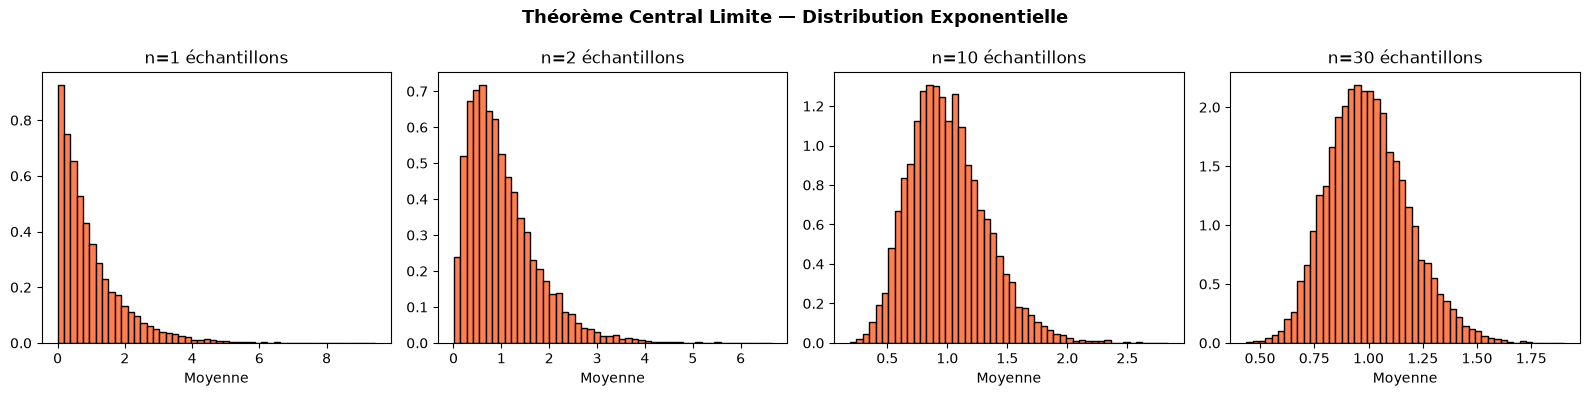

→ n=1  : distribution originale (asymétrique)
→ n=30 : la moyenne suit une loi normale !
→ C'est pourquoi on peut utiliser les stats sur presque n'importe quelles données


In [10]:
# Théorème Central Limite
# Quelle que soit la distribution originale,
# la moyenne de n échantillons suit une loi normale quand n est grand

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
tailles = [1, 2, 10, 30]

for i, n in enumerate(tailles):
    moyennes = [np.mean(np.random.exponential(1, size=n)) for _ in range(10000)]
    axes[i].hist(moyennes, bins=50, color="coral", edgecolor="black", density=True)
    axes[i].set_title(f"n={n} échantillons")
    axes[i].set_xlabel("Moyenne")

plt.suptitle("Théorème Central Limite — Distribution Exponentielle",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("→ n=1  : distribution originale (asymétrique)")
print("→ n=30 : la moyenne suit une loi normale !")
print("→ C'est pourquoi on peut utiliser les stats sur presque n'importe quelles données")

In [6]:
# Entropie = mesure de l'incertitude / désordre
# Cross-Entropy = la loss la plus utilisée en classification

# Entropie H(p) = -Σ p(x) × log₂(p(x))

def entropie(probas):
    probas = np.array(probas)
    probas = probas[probas > 0]  # éviter log(0)
    return -np.sum(probas * np.log2(probas))

# Cas 1 : certitude totale (une seule classe possible)
p_certain = [1.0, 0.0, 0.0]
print(f"Entropie certitude totale : {entropie(p_certain):.4f} → 0 = pas d'incertitude")

# Cas 2 : incertitude maximale (toutes classes équiprobables)
p_uniforme = [1/3, 1/3, 1/3]
print(f"Entropie uniforme (3 classes) : {entropie(p_uniforme):.4f} → maximum d'incertitude")

# Cas 3 : intermédiaire
p_inter = [0.7, 0.2, 0.1]
print(f"Entropie intermédiaire : {entropie(p_inter):.4f}")

print("\n=== CROSS-ENTROPY (loss de classification) ===")
# Cross-Entropy L = -Σ y_vrai × log(y_prédit)

def cross_entropy(y_vrai, y_predit):
    y_predit = np.clip(y_predit, 1e-10, 1)  # éviter log(0)
    return -np.sum(y_vrai * np.log(y_predit))

# Bon modèle : prédit proche de la vérité
y_vrai   = [1, 0, 0]   # vraie classe = classe 0
y_bon    = [0.95, 0.03, 0.02]   # très confiant et correct
y_moyen  = [0.6, 0.3, 0.1]     # moins confiant
y_mauvais = [0.1, 0.8, 0.1]    # complètement faux

print(f"Loss bon modèle    : {cross_entropy(y_vrai, y_bon):.4f}")
print(f"Loss modèle moyen  : {cross_entropy(y_vrai, y_moyen):.4f}")
print(f"Loss mauvais modèle: {cross_entropy(y_vrai, y_mauvais):.4f}")
print("\n→ Plus la loss est faible, mieux le modèle prédit !")

Entropie certitude totale : -0.0000 → 0 = pas d'incertitude
Entropie uniforme (3 classes) : 1.5850 → maximum d'incertitude
Entropie intermédiaire : 1.1568

=== CROSS-ENTROPY (loss de classification) ===
Loss bon modèle    : 0.0513
Loss modèle moyen  : 0.5108
Loss mauvais modèle: 2.3026

→ Plus la loss est faible, mieux le modèle prédit !


In [5]:
# Théorème de Bayes : P(A|B) = P(B|A) × P(A) / P(B)
# Exemple concret : test médical pour une maladie rare

# Données du problème
P_maladie = 0.001        # 0.1% de la population est malade
P_positif_si_malade = 0.99   # test positif si malade = 99%
P_positif_si_sain = 0.05     # faux positif = 5%

# P(positif) = P(positif|malade)×P(malade) + P(positif|sain)×P(sain)
P_sain = 1 - P_maladie
P_positif = (P_positif_si_malade * P_maladie + 
             P_positif_si_sain * P_sain)

# Bayes : P(malade|positif) = P(positif|malade) × P(malade) / P(positif)
P_malade_si_positif = (P_positif_si_malade * P_maladie) / P_positif

print("=== THÉORÈME DE BAYES ===")
print(f"P(malade)              = {P_maladie:.3f} → 0.1% population")
print(f"P(positif | malade)    = {P_positif_si_malade:.3f} → test très sensible")
print(f"P(positif | sain)      = {P_positif_si_sain:.3f} → 5% faux positifs")
print(f"P(positif)             = {P_positif:.4f}")
print(f"\nP(malade | positif)    = {P_malade_si_positif:.4f}")
print(f"\n→ Si ton test est positif, tu n'as que {P_malade_si_positif*100:.1f}% de chances d'être vraiment malade !")
print("→ Contre-intuitif mais mathématiquement correct")
print("→ C'est pourquoi les maladies rares sont difficiles à diagnostiquer")

=== THÉORÈME DE BAYES ===
P(malade)              = 0.001 → 0.1% population
P(positif | malade)    = 0.990 → test très sensible
P(positif | sain)      = 0.050 → 5% faux positifs
P(positif)             = 0.0509

P(malade | positif)    = 0.0194

→ Si ton test est positif, tu n'as que 1.9% de chances d'être vraiment malade !
→ Contre-intuitif mais mathématiquement correct
→ C'est pourquoi les maladies rares sont difficiles à diagnostiquer


=== TAILLE ===
Moyenne  : 169.59 cm
Médiane  : 169.96 cm
Écart-type : 9.29 cm
Min : 143.80 | Max : 197.20

=== CORRÉLATION ===
Corrélation taille-poids : 0.6492
→ Proche de 1 = forte corrélation positive


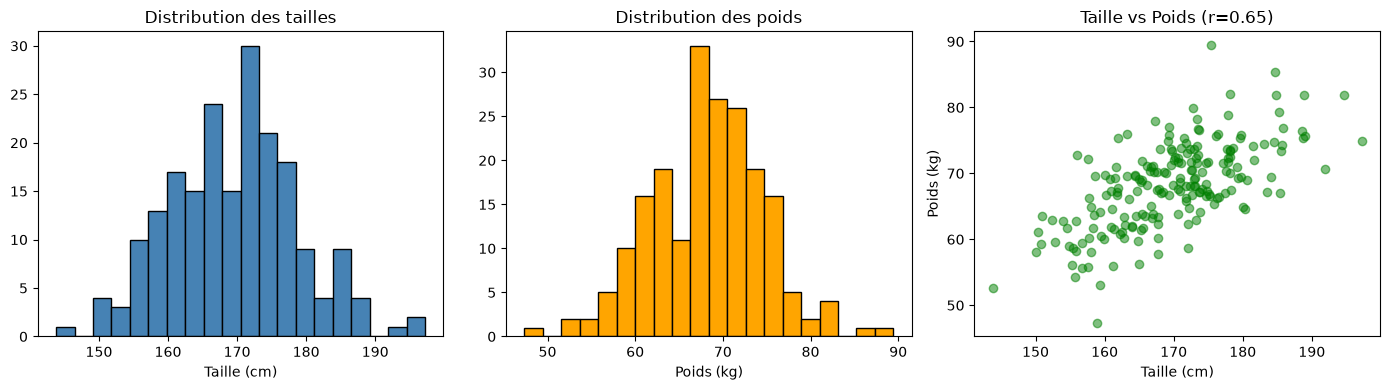

In [3]:
# Statistiques descriptives sur un vrai dataset simulé
np.random.seed(42)

# Simuler des données : taille et poids de 200 personnes
taille = np.random.normal(170, 10, 200)   # μ=170cm, σ=10
poids  = taille * 0.4 + np.random.normal(0, 5, 200)  # corrélé à la taille

print("=== TAILLE ===")
print(f"Moyenne  : {np.mean(taille):.2f} cm")
print(f"Médiane  : {np.median(taille):.2f} cm")
print(f"Écart-type : {np.std(taille):.2f} cm")
print(f"Min : {np.min(taille):.2f} | Max : {np.max(taille):.2f}")

print("\n=== CORRÉLATION ===")
correlation = np.corrcoef(taille, poids)[0, 1]
print(f"Corrélation taille-poids : {correlation:.4f}")
print("→ Proche de 1 = forte corrélation positive")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(taille, bins=20, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution des tailles")
axes[0].set_xlabel("Taille (cm)")

axes[1].hist(poids, bins=20, color="orange", edgecolor="black")
axes[1].set_title("Distribution des poids")
axes[1].set_xlabel("Poids (kg)")

axes[2].scatter(taille, poids, alpha=0.5, color="green")
axes[2].set_title(f"Taille vs Poids (r={correlation:.2f})")
axes[2].set_xlabel("Taille (cm)")
axes[2].set_ylabel("Poids (kg)")

plt.tight_layout()
plt.show()

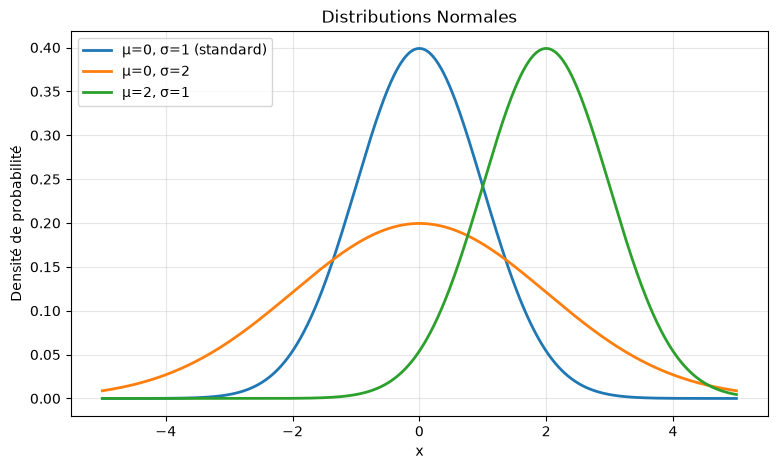

Règle empirique (μ=0, σ=1) :
P(μ-σ < X < μ+σ)   = 0.6827 → ~68%
P(μ-2σ < X < μ+2σ) = 0.9545 → ~95%
P(μ-3σ < X < μ+3σ) = 0.9973 → ~99.7%


In [2]:
# Distribution Normale (Gaussienne)
# Forme : courbe en cloche
# Paramètres : μ (moyenne) et σ (écart-type)

from scipy import stats

x = np.linspace(-5, 5, 1000)

# Différentes distributions normales
configs = [
    (0, 1, "μ=0, σ=1 (standard)"),
    (0, 2, "μ=0, σ=2"),
    (2, 1, "μ=2, σ=1"),
]

plt.figure(figsize=(9, 5))
for mu, sigma, label in configs:
    y = stats.norm.pdf(x, mu, sigma)
    plt.plot(x, y, linewidth=2, label=label)

plt.title("Distributions Normales")
plt.xlabel("x"); plt.ylabel("Densité de probabilité")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Règle 68-95-99.7
mu, sigma = 0, 1
print("Règle empirique (μ=0, σ=1) :")
print(f"P(μ-σ < X < μ+σ)   = {stats.norm.cdf(1)-stats.norm.cdf(-1):.4f} → ~68%")
print(f"P(μ-2σ < X < μ+2σ) = {stats.norm.cdf(2)-stats.norm.cdf(-2):.4f} → ~95%")
print(f"P(μ-3σ < X < μ+3σ) = {stats.norm.cdf(3)-stats.norm.cdf(-3):.4f} → ~99.7%")

P(face=1) = 0.1665  → théorique = 0.1667
P(face=2) = 0.1692  → théorique = 0.1667
P(face=3) = 0.1625  → théorique = 0.1667
P(face=4) = 0.1672  → théorique = 0.1667
P(face=5) = 0.1689  → théorique = 0.1667
P(face=6) = 0.1657  → théorique = 0.1667


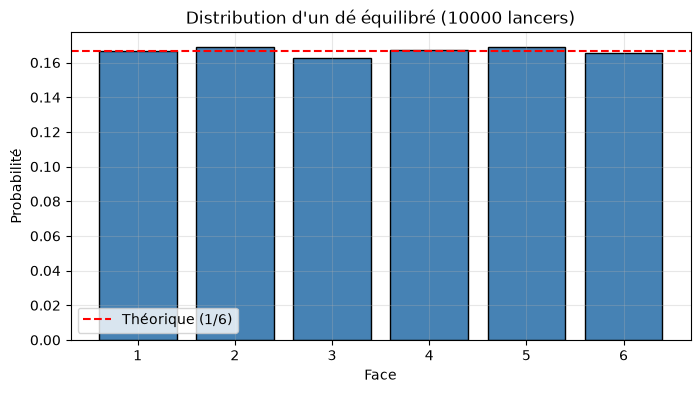

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simuler un lancer de dé 10000 fois
np.random.seed(42)
lancers = np.random.randint(1, 7, size=10000)

# Probabilité de chaque face
for face in range(1, 7):
    prob = np.sum(lancers == face) / len(lancers)
    print(f"P(face={face}) = {prob:.4f}  → théorique = 0.1667")

# Visualisation
plt.figure(figsize=(8, 4))
faces, counts = np.unique(lancers, return_counts=True)
plt.bar(faces, counts/len(lancers), color="steelblue", edgecolor="black")
plt.axhline(1/6, color="red", linestyle="--", label="Théorique (1/6)")
plt.title("Distribution d'un dé équilibré (10000 lancers)")
plt.xlabel("Face"); plt.ylabel("Probabilité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()